In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [38]:
df=pd.read_csv('CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [39]:
def clean_dataframe(df:pd.DataFrame, 
                    verbose:bool=True)-> pd.DataFrame:
    df=df.copy()

    def log(msg):
        if verbose:
            print(f'INFO: {msg}')
    
    # 1. column names
    df.columns=df.columns.str.strip().str.lower().str.replace(' ','_')
    log('Standardized column names')

    # 2. drop duplicates
    dup_count=df.duplicated().sum()
    if dup_count>0:
        df.drop_duplicates(inplace=True)
        log(f'Removed {dup_count} duplicate rows')

    # 3. string data
    for col in df.select_dtypes(include='object'):
        df[col]=df[col].astype('str').str.strip().str.lower()
    log('Standardized string columns')

    # 4. null values
    placeholder_values = ['n/a', 'na', '--', '-', 'none', 'null', '', 'nan']
    df.replace(placeholder_values,np.nan, inplace=True)
    null_report=df.isnull().sum()
    null_report = null_report[null_report > 0]
    if not null_report.empty:
        log(f"Missing values found in columns:\n{null_report}")

    # 5. constant columns
    constant_cols=[col for col in df.columns if df[col].nunique()==1]
    if constant_cols:
        log(f'Constant columns (consider removing): {constant_cols}')
    
    # 6. encoding
    high_card_cols=[col for col in df.select_dtypes(include='object') if df[col].nunique()>100]
    if high_card_cols:
        log(f"High-cardinality columns (consider encoding strategies): {high_card_cols}")

    # 7. category data
    for col in df.select_dtypes(include='object'):
        n_unique=df[col].nunique()
        if n_unique< len(df)*0.05:
            df[col]=df[col].astype('category')
    log("Converted suitable object columns to category dtype.")

    # 8. outliers
    num_cols= df.select_dtypes(include=np.number).columns
    outlier_report={}
    for col in num_cols:
        q1, q3=df[col].quantile([0.25,0.75])
        iqr=q3-q1
        lower=q1-1.5*iqr
        upper=q3+1.5*iqr
        outliers=df[(df[col]<lower)|(df[col]>upper)][col].count()
        if outliers>0:
            outlier_report[col]=outliers
    if outlier_report:
        log(f"Potential numeric outliers detected:\n{outlier_report}")


    log("Data cleaning complete.")
    return df

In [40]:
df=clean_dataframe(df, verbose=True)
df.head()

INFO: Standardized column names
INFO: Standardized string columns
INFO: Missing values found in columns:
credit_limit          1
minimum_payments    313
dtype: int64
INFO: High-cardinality columns (consider encoding strategies): ['cust_id']
INFO: Converted suitable object columns to category dtype.
INFO: Potential numeric outliers detected:
{'balance': np.int64(695), 'balance_frequency': np.int64(1493), 'purchases': np.int64(808), 'oneoff_purchases': np.int64(1013), 'installments_purchases': np.int64(867), 'cash_advance': np.int64(1030), 'oneoff_purchases_frequency': np.int64(782), 'cash_advance_frequency': np.int64(525), 'cash_advance_trx': np.int64(804), 'purchases_trx': np.int64(766), 'credit_limit': np.int64(248), 'payments': np.int64(808), 'minimum_payments': np.int64(841), 'prc_full_payment': np.int64(1474), 'tenure': np.int64(1366)}
INFO: Data cleaning complete.


,cust_id,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,c10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,c10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,c10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,c10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,c10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [41]:
df = df.dropna()

In [42]:
clustering_data= df[['balance','purchases','credit_limit']]
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
kmeans = make_pipeline(MinMaxScaler(),KMeans(n_clusters=5))
clusters = kmeans.fit_predict(clustering_data)
df['credit_card_segments'] = clusters

In [43]:
df["credit_card_segments"] = df["credit_card_segments"].map({0: "Cluster 1", 1: 
    "Cluster 2", 2: "Cluster 3", 3: "Cluster 4", 4: "Cluster 5"})
print(df["credit_card_segments"].head(10))

0     Cluster 4
1     Cluster 2
2     Cluster 2
4     Cluster 4
5     Cluster 4
6     Cluster 5
7     Cluster 4
8     Cluster 1
9     Cluster 5
10    Cluster 4
Name: credit_card_segments, dtype: object


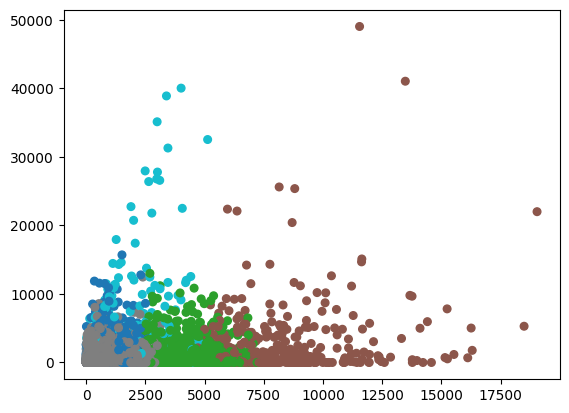

In [44]:
plt.scatter(clustering_data.values[:, 0], clustering_data.values[:, 1], c=clusters, cmap='tab10', s=30)
plt.show()